## Experiment results

In [ ]:
from pathlib import Path
import sys
import json
import os

IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")
except:
  IN_COLAB = False
  print("Not running as a Colab notebook")

if IN_COLAB:
  %pip install transformer_lens
  from google.colab import drive
  drive.mount('/content/drive')
  ! pwd # Returns /content
  ! cp "/content/drive/MyDrive/Colab Notebooks/patching_algorithms_for_presentation.py" /content/patching_algorithms.py
  ! cp "/content/drive/MyDrive/Colab Notebooks/temporal_scope_for_attribution_patching_for_qwen3.json" /content/temporal_scope_for_attribution_patching.json
  import patching_algorithms

import plotly.express as px
import plotly.io as pio
import pandas as pd

Running as a Colab notebook
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content


### 1. Define the model of interest

In [ ]:
MODEL_NAME = "Qwen/Qwen3-4B"
#MODEL_NAME = "phi-3"

### 2. Read the dataset, prepare inputs for "short" circuits

In [ ]:
clean_prompts = [
    "When John and Mary went to the shops, John gave the bag to",
    "When Tom and James went to the park, James gave the ball to",
    "When Dan and Sid went to the shops, Sid gave an apple to",
    "After Martin and Amy went to the park, Amy gave a drink to",

]
corrupted_prompts = [
    "When John and Mary went to the shops, Mary gave the bag to",
    "When Tom and James went to the park, Tom gave the ball to",
    "When Dan and Sid went to the shops, Dan gave an apple to",
    "After Martin and Amy went to the park, Martin gave a drink to",
]
answers = [
    (" Mary", " John"),
    (" Tom", " James"),
    (" Dan", " Sid"),
    (" Martin", " Amy"),
]

clean_answers = []
corrupted_answers = []

for i in range(0, len(clean_prompts)):
  clean_answers.append(answers[i][0])
  corrupted_answers.append(answers[i][1])


### Run Activation patching function

In [ ]:
class ExperimentResult:
  def __init__(self, name, metric_name, technique_name, layers_pos_scores):
    self.name = name
    self.metric_name = metric_name
    self.technique_name = technique_name
    self.layers_pos_scores = layers_pos_scores.copy()
    self.layers_scores_avg = self.layers_pos_scores.mean(axis=1)

def run_full_activation_patching_experiment(model_name, clean_prompts, clean_answers, corrupted_prompts, corrupted_answers):
  techniques_to_run = [("Denoising", patching_algorithms.ActivationPatching.Technique.DENOISING),
                       ("Denoising_Both_Logprobs", patching_algorithms.ActivationPatching.Technique.DENOISING_BOTH_LOGPROBS),
                       ("Denoising_Custom", patching_algorithms.ActivationPatching.Technique.DENOISING_CUSTOM),
                       ("Denoising_Both_Logprobs_Custom", patching_algorithms.ActivationPatching.Technique.DENOISING_BOTH_LOGPROBS_CUSTOM),
                       ("Noising", patching_algorithms.ActivationPatching.Technique.NOISING),
                       ("Noising_Both_Logprobs", patching_algorithms.ActivationPatching.Technique.NOISING_BOTH_LOGPROBS),
                       ("Noising_Custom", patching_algorithms.ActivationPatching.Technique.NOISING_CUSTOM),
                       ("Noising_Both_Logprobs_Custom", patching_algorithms.ActivationPatching.Technique.NOISING_BOTH_LOGPROBS_CUSTOM)]
  metrics_to_run = [("logit_diff", patching_algorithms.ActivationPatching.Metric.LOGIT_DIFF)]
  residual_results = []
  attn_out_results = []
  mlp_out_results = []
  for technique_name, technique_type in techniques_to_run:
      for metric_name, metric_type in metrics_to_run:
          print(f"\n\n\nRunning experiment for technique: {technique_name}, metric: {metric_name}!")
          act_patch = patching_algorithms.ActivationPatching(MODEL_NAME,
                                                            clean_prompts, clean_answers,
                                                            corrupted_prompts, corrupted_answers,
                                                            metric_type, technique_type, patching_algorithms.ActivationPatching.Viz.READER_FRIENDLY)
          print("\n\n\nRunning residual patching...")
          result = act_patch.patch_residual()
          if isinstance(result, tuple):
            residual_results.append(ExperimentResult(f"residual_{metric_name}_{technique_name}_direct", metric_name, technique_name, result[0]))
            residual_results.append(ExperimentResult(f"residual_{metric_name}_{technique_name}_anti", metric_name, technique_name, result[1]))
          else:
            residual_results.append(ExperimentResult(f"residual_{metric_name}_{technique_name}_direct", metric_name, technique_name, result))
          print("Residual patching - Done.")
          print("\n\n\nRunning attention output patching...")
          attn_result = act_patch.patch_attn_out()
          if isinstance(attn_result, tuple):
            attn_out_results.append(ExperimentResult(f"attn_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, attn_result[0]))
            attn_out_results.append(ExperimentResult(f"attn_out_{metric_name}_{technique_name}_anti", metric_name, technique_name, attn_result[1]))
          else:
            attn_out_results.append(ExperimentResult(f"attn_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, attn_result))
          print("Attention output patching - Done.")
          print("\n\n\nRunning MLP output patching...")
          mlp_result = act_patch.patch_mlp_out()
          if isinstance(mlp_result, tuple):
            mlp_out_results.append(ExperimentResult(f"mlp_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, mlp_result[0]))
            mlp_out_results.append(ExperimentResult(f"mlp_out_{metric_name}_{technique_name}_anti", metric_name, technique_name, mlp_result[1]))
          else:
            mlp_out_results.append(ExperimentResult(f"mlp_out_{metric_name}_{technique_name}_direct", metric_name, technique_name, mlp_result))
          print("MLP output patching - Done.")

          print("Cleaning the memory...")
          del act_patch

          import gc
          gc.collect()
  return residual_results, attn_out_results, mlp_out_results

Run full Activation patching experiment for "short" clean prompts and "long" corrupted ones.
- The experiment is run for three metrics: *logit_diff*, *logprob* and *logit* (Correct for mean = 0 in logit experiment!).
- The experiment is run for denoising and noising techniques.

In [ ]:
clean_short_res, clean_short_attn, clean_short_mlp = run_full_activation_patching_experiment(MODEL_NAME, clean_prompts, clean_answers, corrupted_prompts, corrupted_answers)




Running experiment for technique: Denoising, metric: logit_diff!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer
Clean string 0 <|im_end|>When John and Mary went to the shops, John gave the bag to
Corrupted string 0 <|im_end|>When John and Mary went to the shops, Mary gave the bag to
Clean answers tensor([10244,  8364, 11563, 11565])
Corrupted answers tensor([ 3757,  7801, 33889, 28693])



Running residual patching...
Clean logit TOP-3: [' Mary the Alice', ' Tom his the', ' each Dan the', ' the a Martin']

Corrupted logit TOP-3: [' John the Jane', ' James his the', ' each the a', ' Amy a the']


Clean baseline metric: 12.7042
Corrupted baseline metric: -9.8544


  0%|          | 0/540 [00:00<?, ?it/s]

Residual patching - Done.



Running attention output patching...
Clean logit TOP-3: [' Mary the Alice', ' Tom his the', ' each Dan the', ' the a Martin']

Corrupted logit TOP-3: [' John the Jane', ' James his the', ' each the a', ' Amy a the']


Clean baseline metric: 12.7042
Corrupted baseline metric: -9.8544


...

  0%|          | 0/540 [00:00<?, ?it/s]

Attention output patching - Done.



Running MLP output patching...
Clean logit TOP-3: [' Mary the Alice', ' Tom his the', ' each Dan the', ' the a Martin']

Corrupted logit TOP-3: [' John the Jane', ' James his the', ' each the a', ' Amy a the']


Clean(clean) baseline metric: -1.1289
Corrupted(clean) baseline metric: -11.5654
Clean(corrupted) baseline metric: -13.8332
Corrupted(corrupted) baseline metric: -1.7110


  0%|          | 0/540 [00:00<?, ?it/s]

  0%|          | 0/540 [00:00<?, ?it/s]

MLP output patching - Done.
Cleaning the memory...


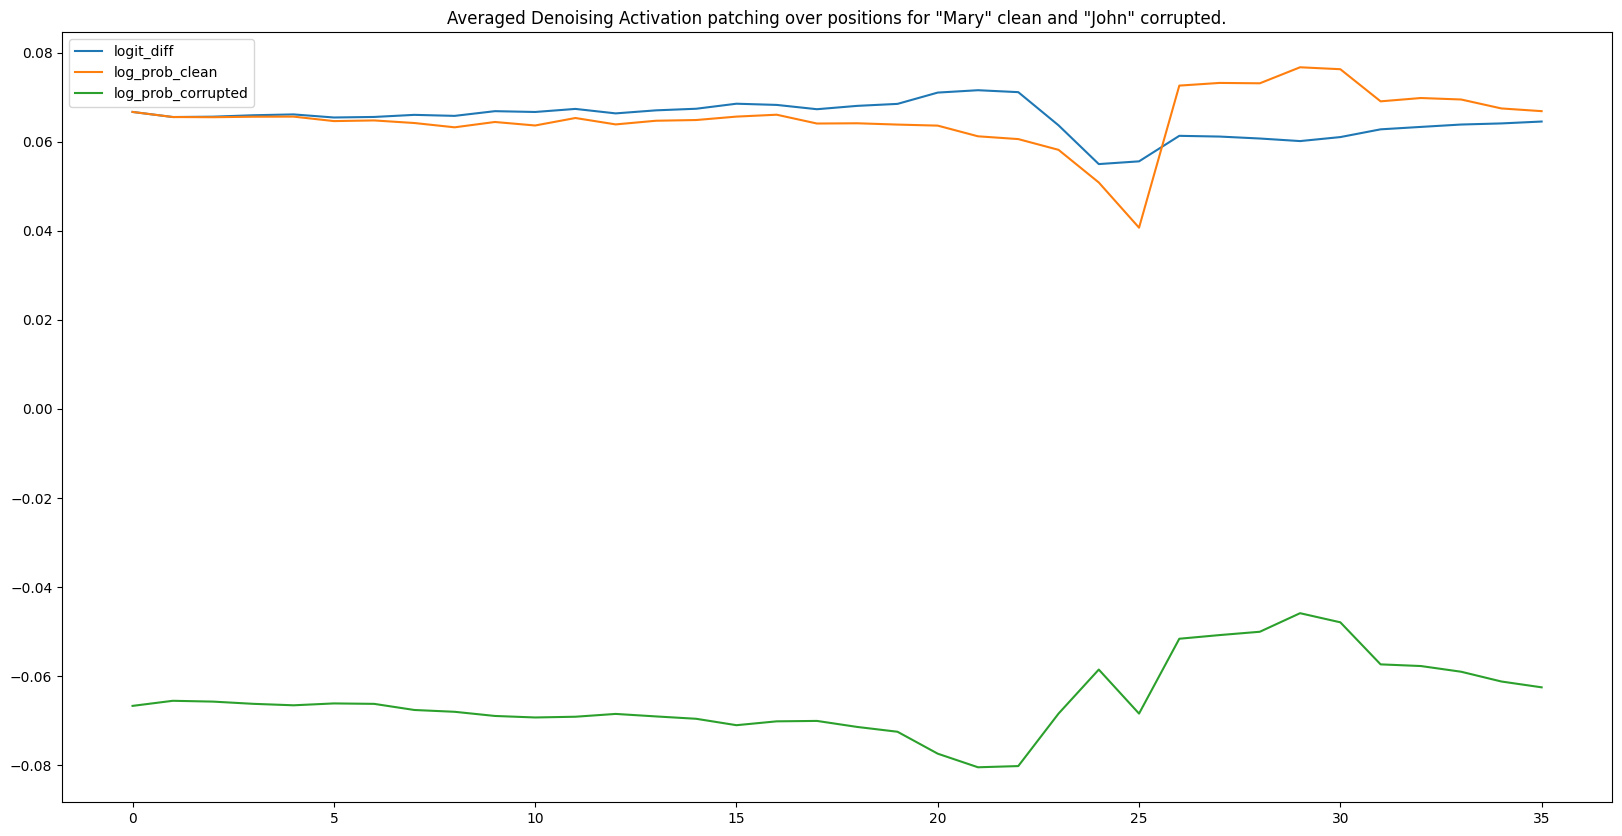

In [ ]:
for res in clean_short_res[:3]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Denoising Activation patching over positions for \"Mary\" clean and \"John\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])


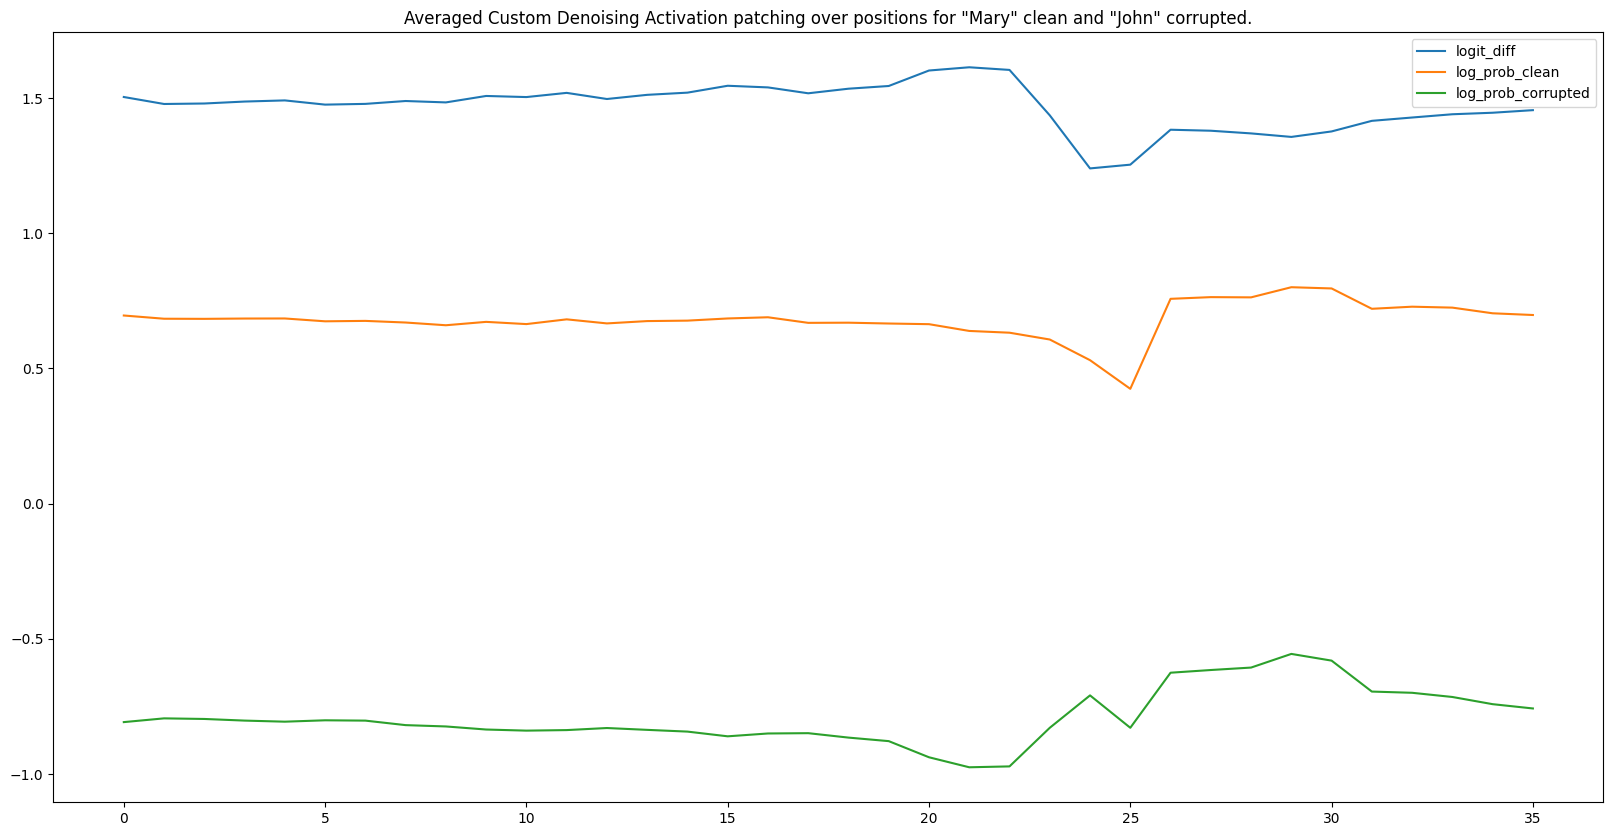

In [ ]:
for res in clean_short_res[3:6]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Custom Denoising Activation patching over positions for \"Mary\" clean and \"John\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])


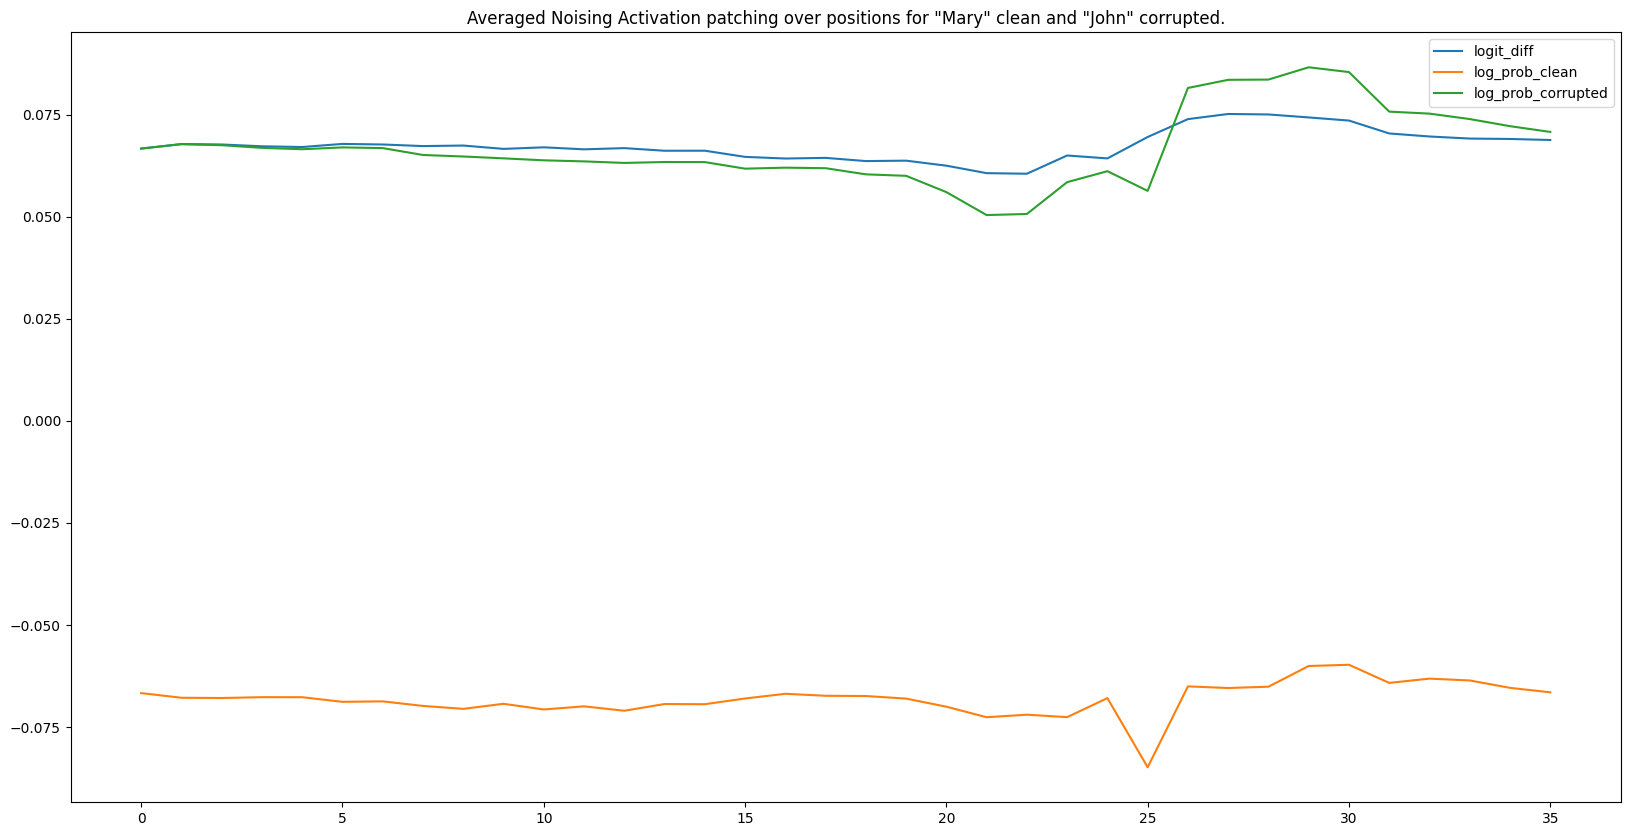

In [ ]:
for res in clean_short_res[6:9]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Noising Activation patching over positions for \"Mary\" clean and \"John\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

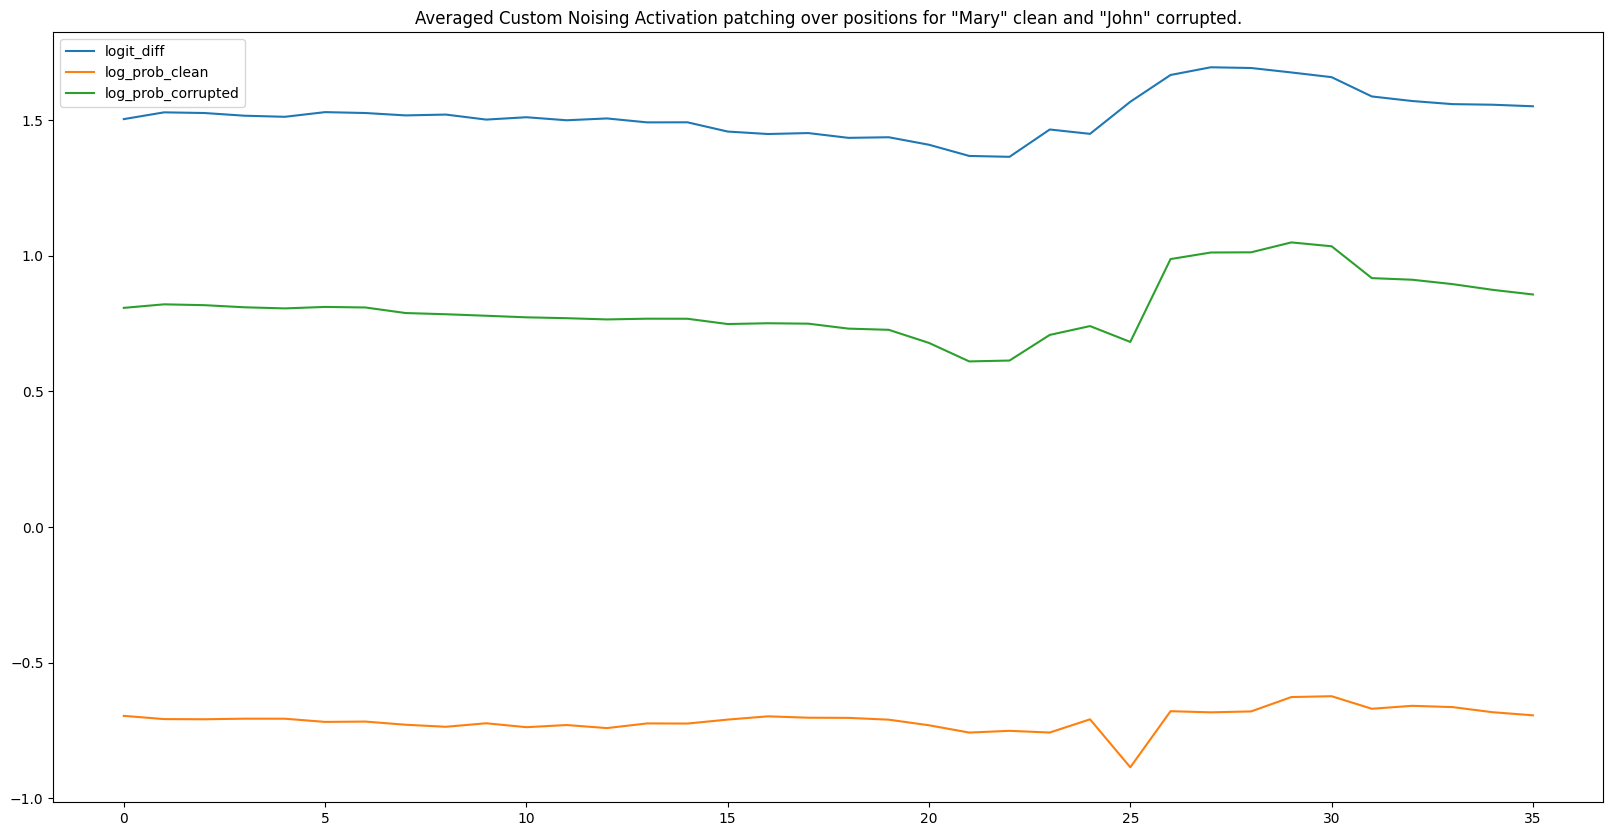

In [ ]:
for res in clean_short_res[9:12]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Custom Noising Activation patching over positions for \"Mary\" clean and \"John\" corrupted.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

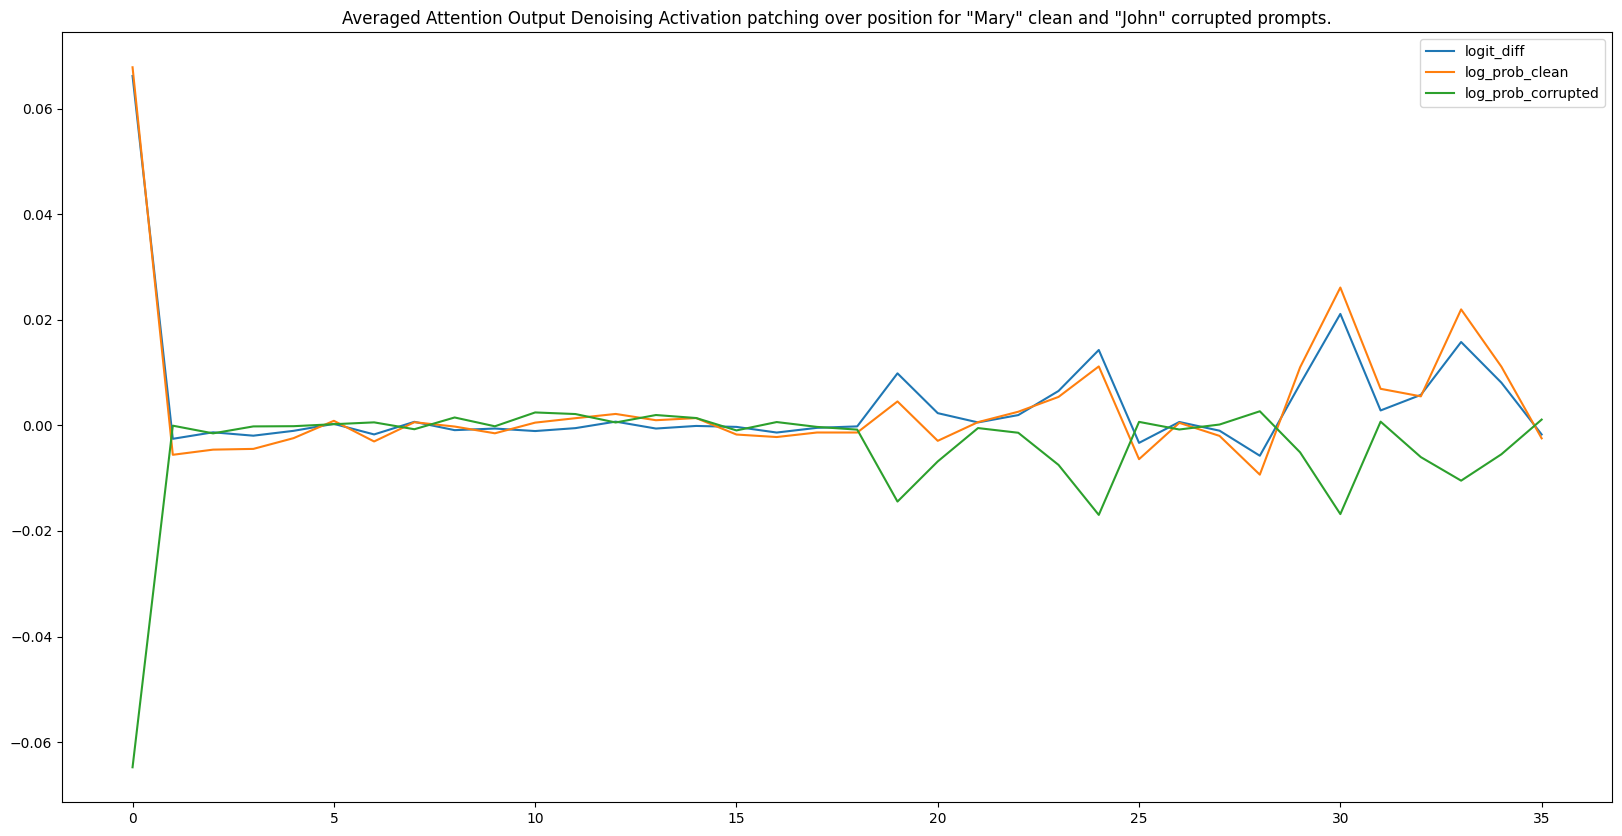

In [ ]:
for res in clean_short_attn[:3]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Denoising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

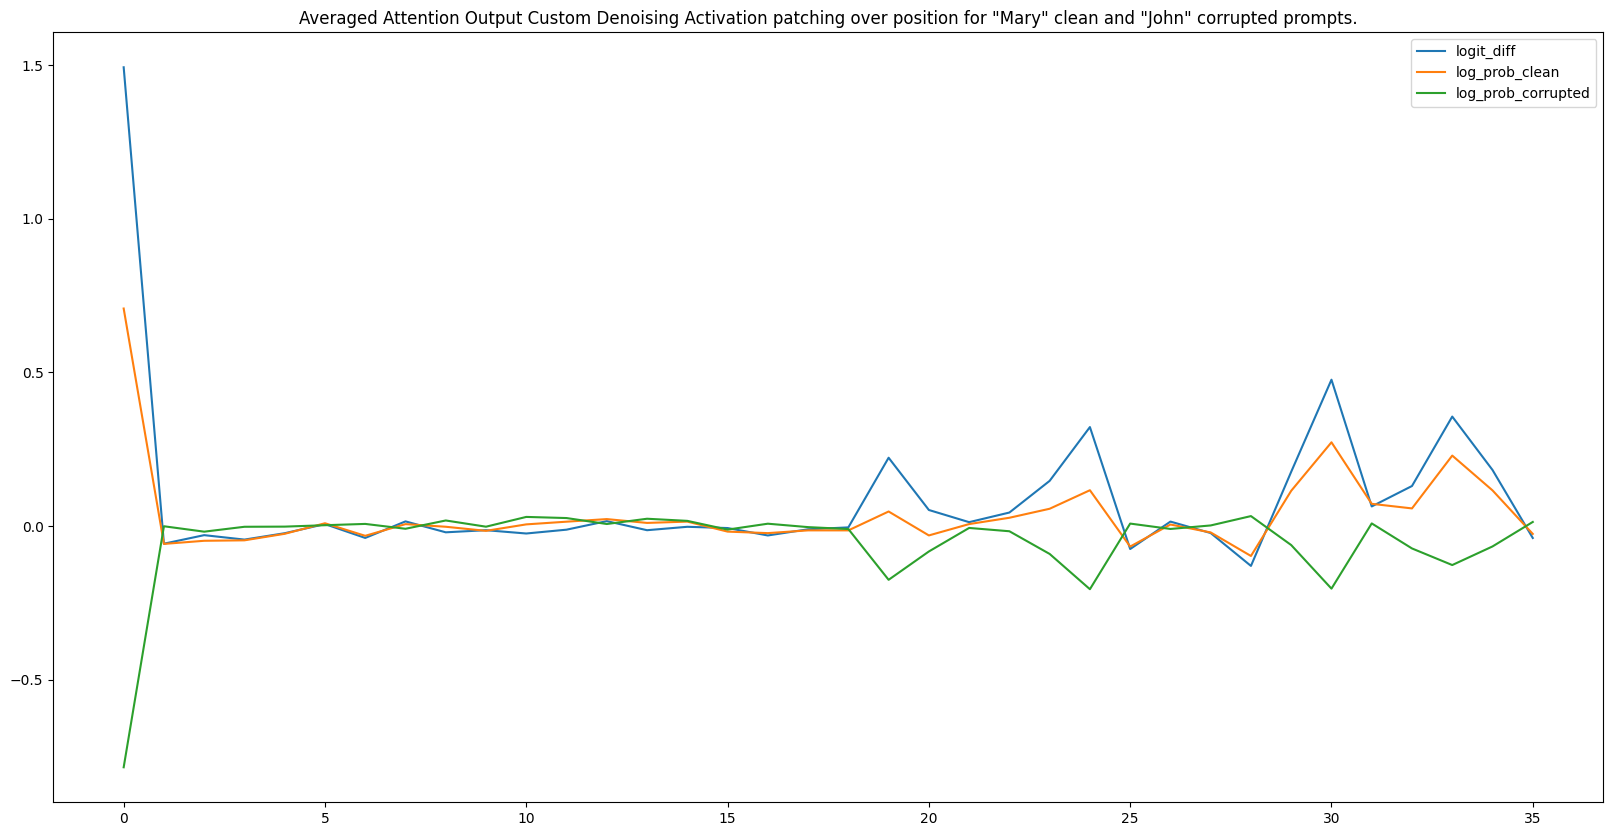

In [ ]:
for res in clean_short_attn[3:6]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Custom Denoising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

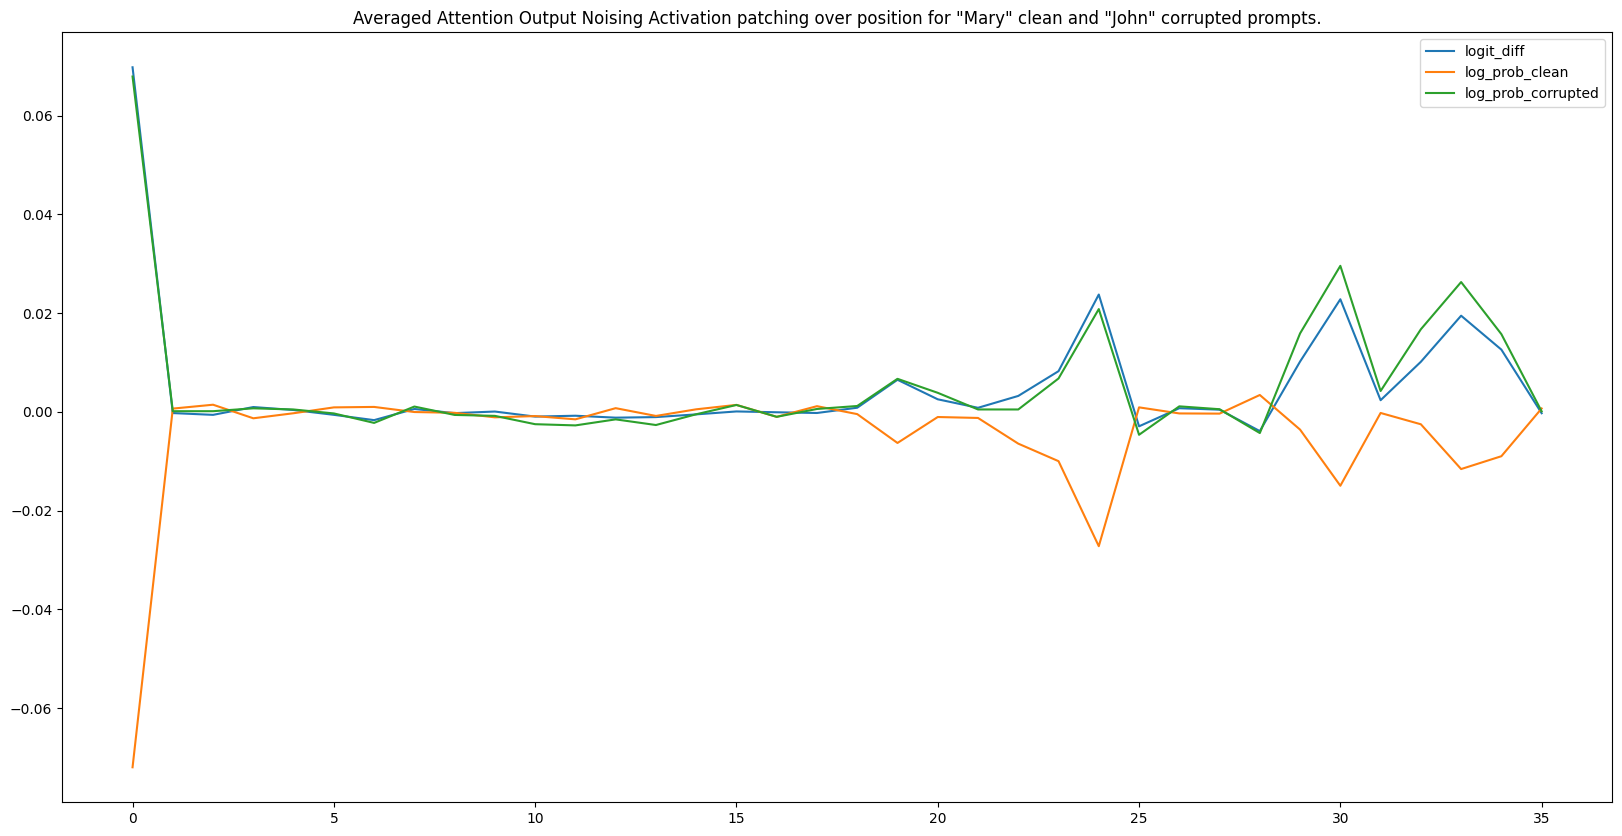

In [ ]:
for res in clean_short_attn[6:9]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Noising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

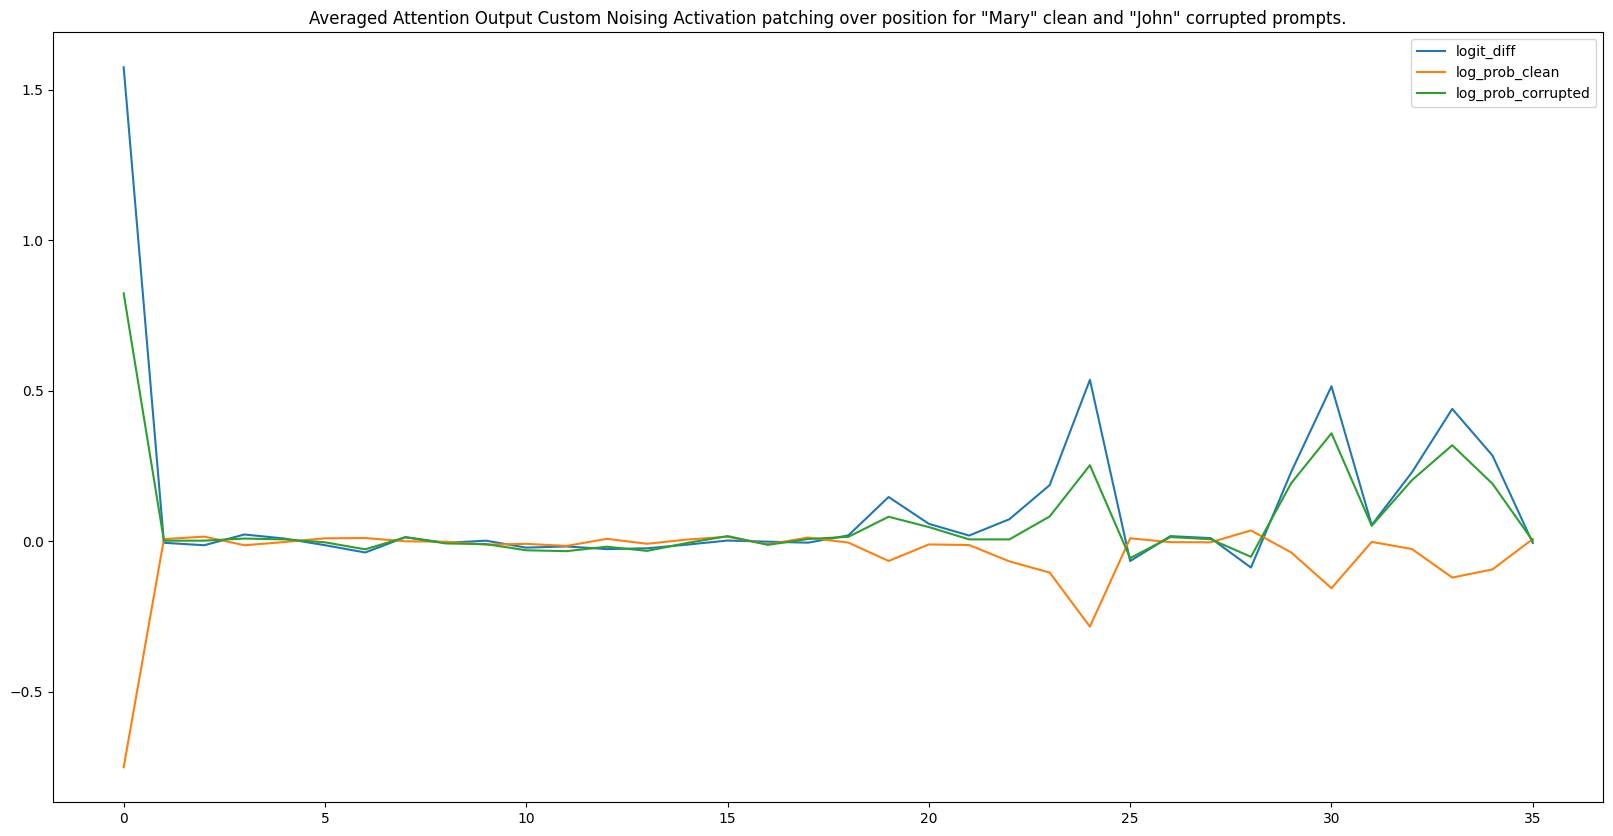

In [ ]:
for res in clean_short_attn[9:12]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged Attention Output Custom Noising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

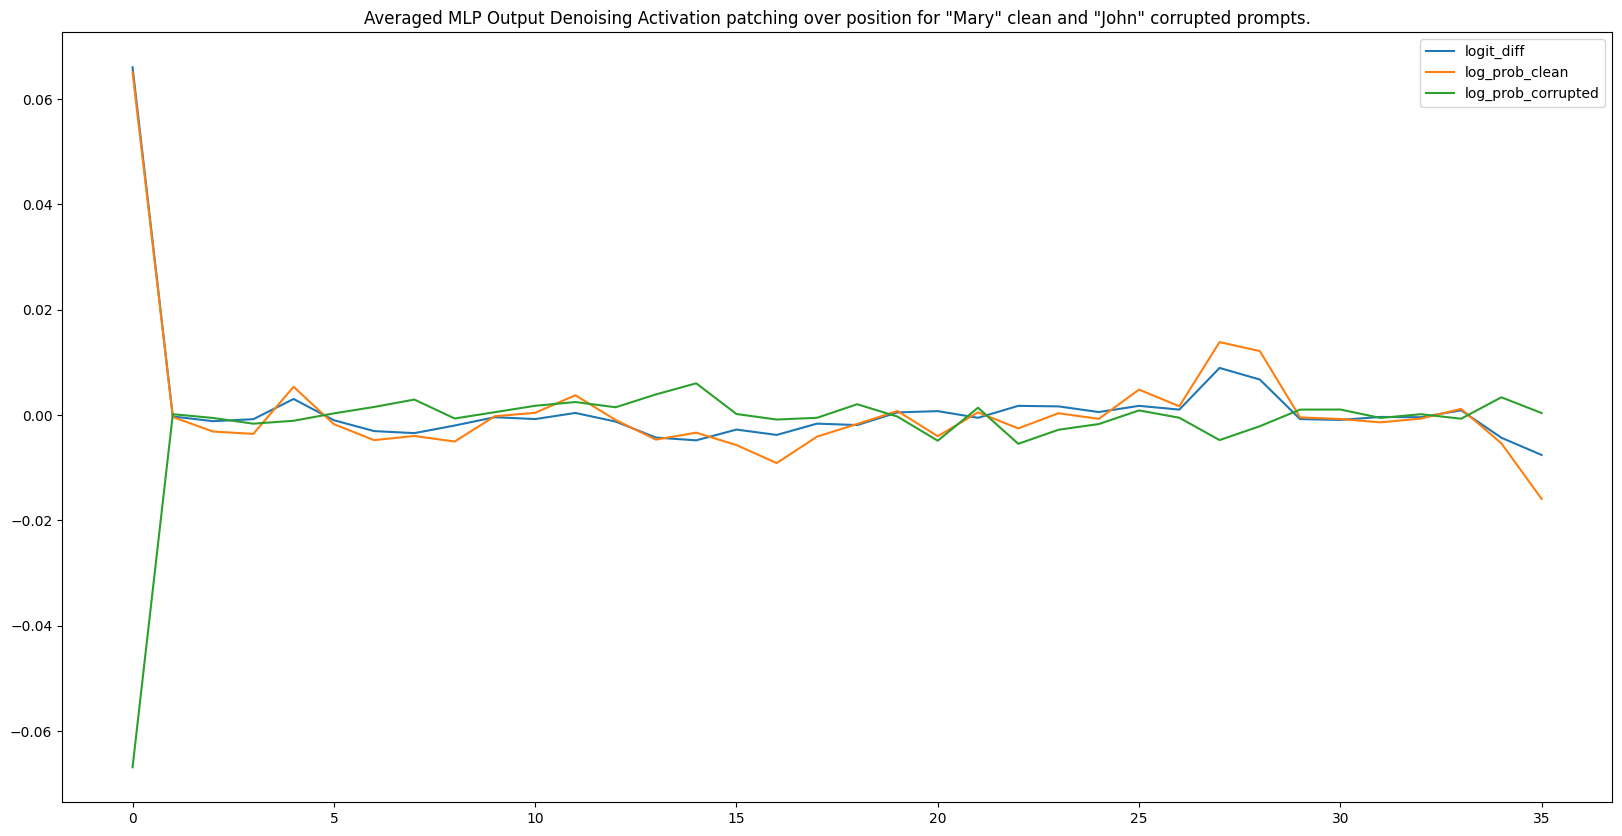

In [ ]:
for res in clean_short_mlp[:3]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Denoising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

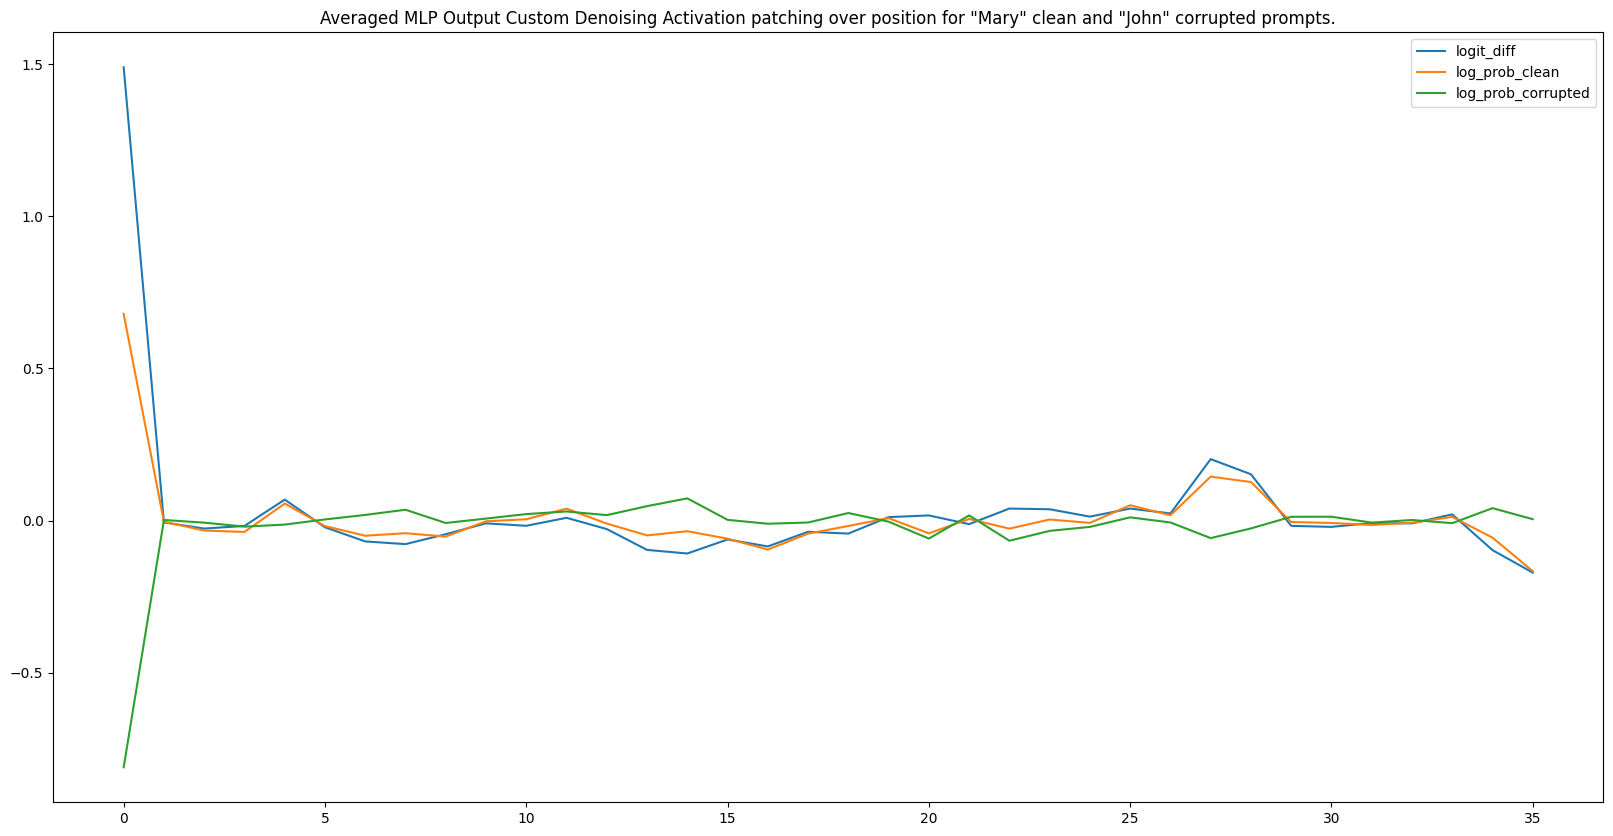

In [ ]:
for res in clean_short_mlp[3:6]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Custom Denoising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

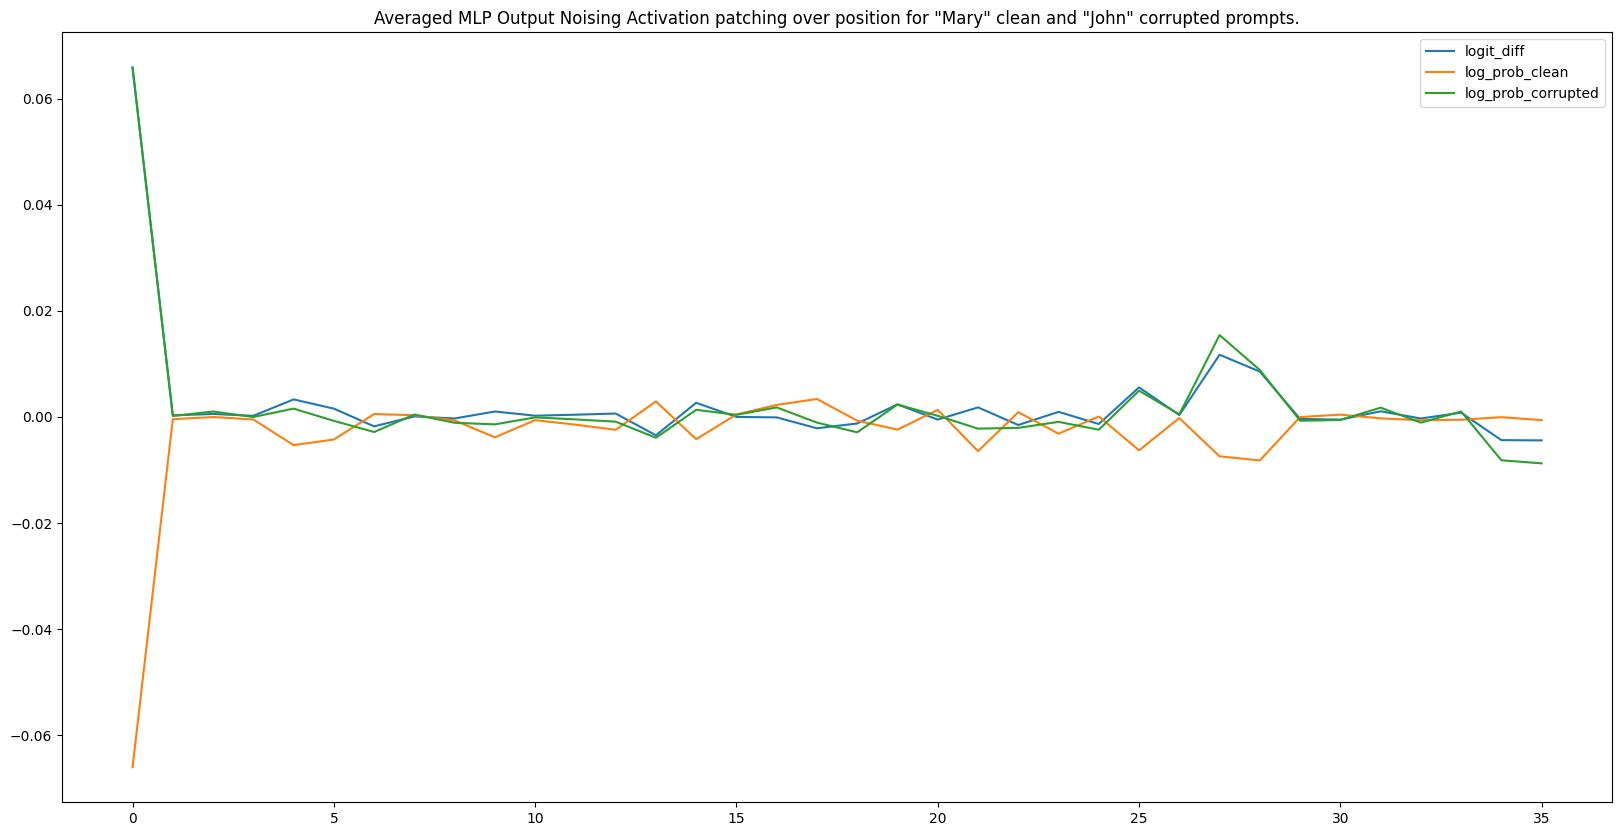

In [ ]:
for res in clean_short_mlp[6:9]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Noising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])

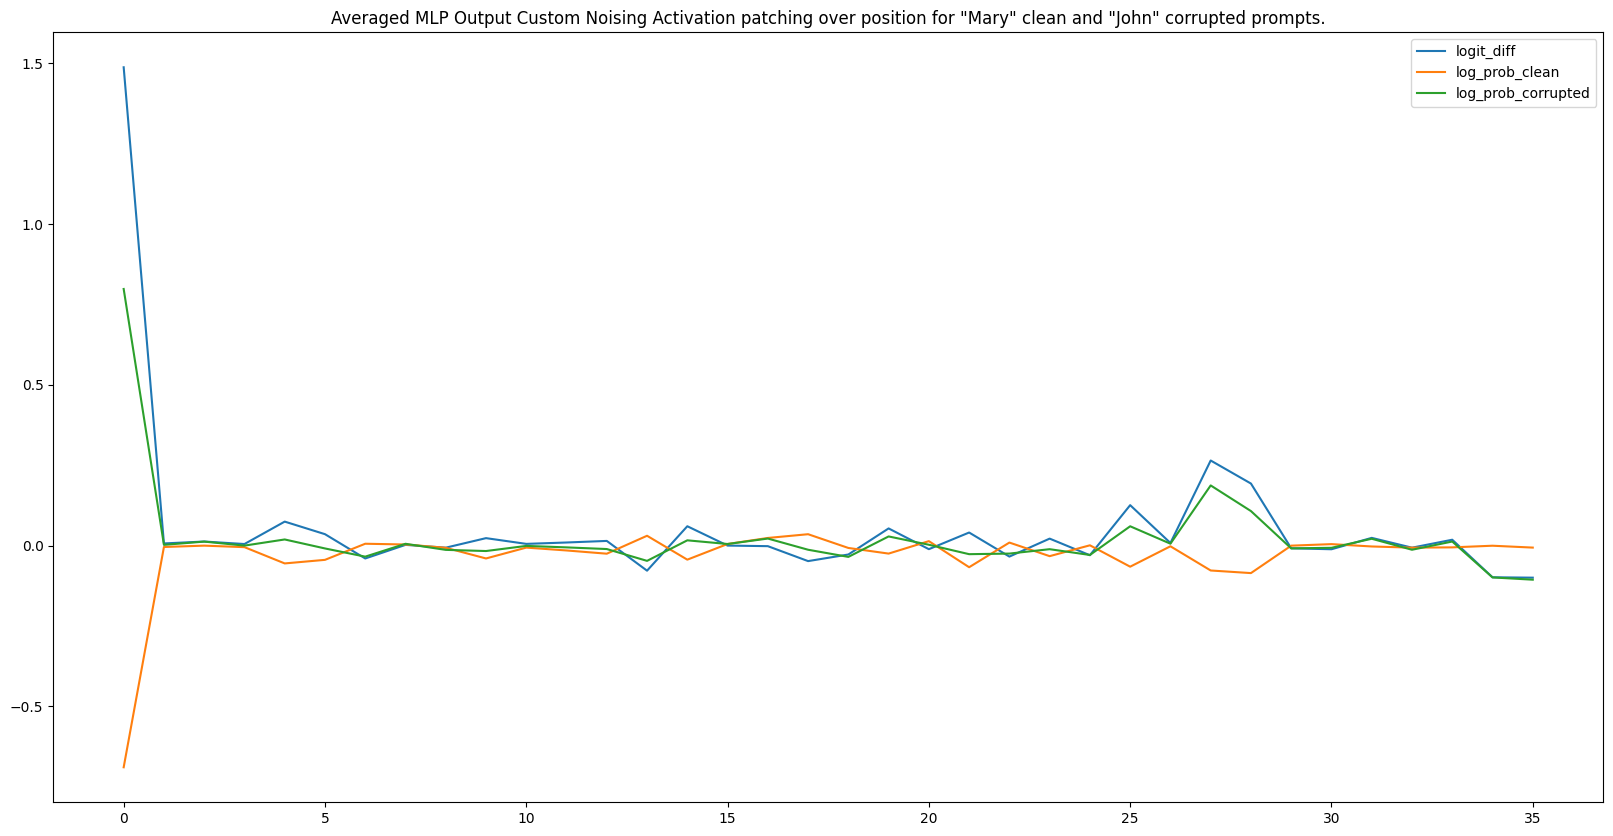

In [ ]:
for res in clean_short_mlp[9:12]:
  import matplotlib.pyplot as plt
  %matplotlib inline
  plt.rcParams["figure.figsize"] = [20, 10]
  ax = res.layers_scores_avg.plot(title=f"Averaged MLP Output Custom Noising Activation patching over position for \"Mary\" clean and \"John\" corrupted prompts.")
ax.legend(["logit_diff", "log_prob_clean", "log_prob_corrupted"])